# SMBHB modelling with MCMC

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import sys
from pathlib import Path
from functools import partial
from matplotlib import pyplot as plt
import polars as pl

import jax
from jax import random
from jax import numpy as jnp
sys.path.append('../src')
jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
numpyro.enable_x64()
numpyro.set_host_device_count(4)

from smbhb_jax import smbhb_two_masses
from inference import make_smbhb_model, make_tinygp_model, drw_kernel, smbhb_mean_builder
from plots import corner_plot, predictive_posterior

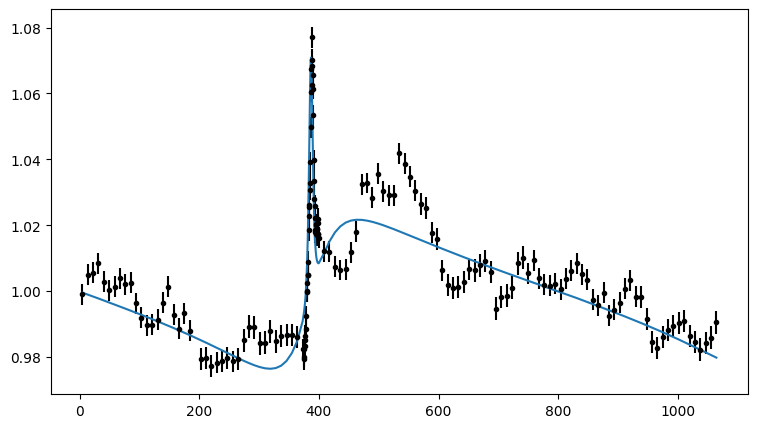

In [11]:
data_path = Path('../data')
#time, flux, flux_err = pl.read_ipc(data_path / 'lc_spikey_fiducial_1d.ftr', memory_map=False).to_numpy().T
#time, flux, flux_err = pl.read_csv(data_path / 'whitenoise_model.csv').select(['time', 'flux', 'flux_err']).to_numpy().T
#time, flux, flux_err = pl.read_csv(data_path / 'data_spikey_kepler_9day.csv').select(['time', 'flux', 'flux_err']).to_numpy().T
time, flux, flux_err = pl.read_csv(data_path / 'data_spikey_kepler_binned.csv').select(['time', 'flux', 'flux_err']).to_numpy().T

# Generate a spare time array for faster modelling
time_interp = jnp.linspace(jnp.amin(time), jnp.amax(time), 500)

# Parameters of Spikey
spikey_params = {
    'z': 0.918, 't0': 1.050, 'P': 1.144, 'i': 81.95, 'e': 0.524, 'w': jnp.rad2deg(1.477),
    'L': 0.89, 'alpha': 2.09, 'vz': 0, 'logM1': 7.4, 'logM2': 6.7,
}

# Show Kepler obs and model from Hu+2020
smbhb_partial = partial(smbhb_two_masses, **spikey_params)
sim_flux = jax.vmap(smbhb_partial)(time)
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, c='k', fmt='.')
ax.plot(time, sim_flux);

---
## 0. Fitting as in Hu+2020
---

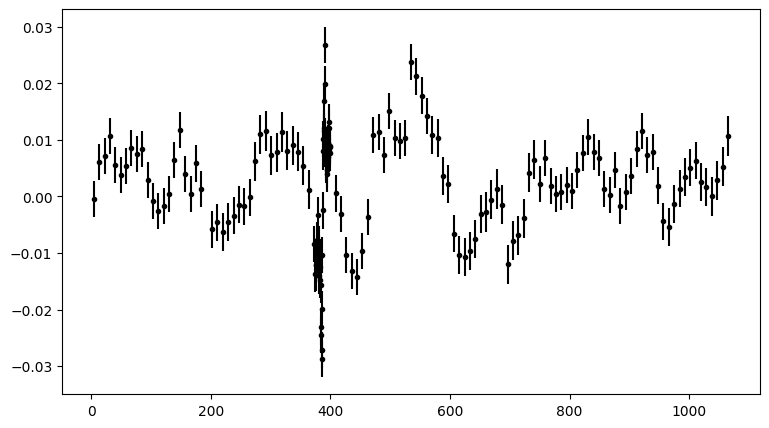

In [12]:
# Show DRW with SMBHB model subtracted
flux_drw = flux - sim_flux
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux_drw, flux_err, c='k', fmt='.');

In [13]:
%%time

priors = {
    'tau': dist.LogNormal(jnp.log(200.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux_drw)), 0.5),
    'mean': dist.Normal(jnp.mean(flux_drw), 0.5),
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=drw_kernel), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux_drw, yerr=flux_err, x_interp=time)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      mean      0.00      0.00      0.00      0.00      0.01  20826.70      1.00
     sigma      0.01      0.00      0.01      0.01      0.01   7128.78      1.00
       tau     18.46      7.31     17.08      9.19     26.85   6179.60      1.00

Number of divergences: 0
CPU times: user 1min 14s, sys: 8.04 s, total: 1min 22s
Wall time: 51.9 s


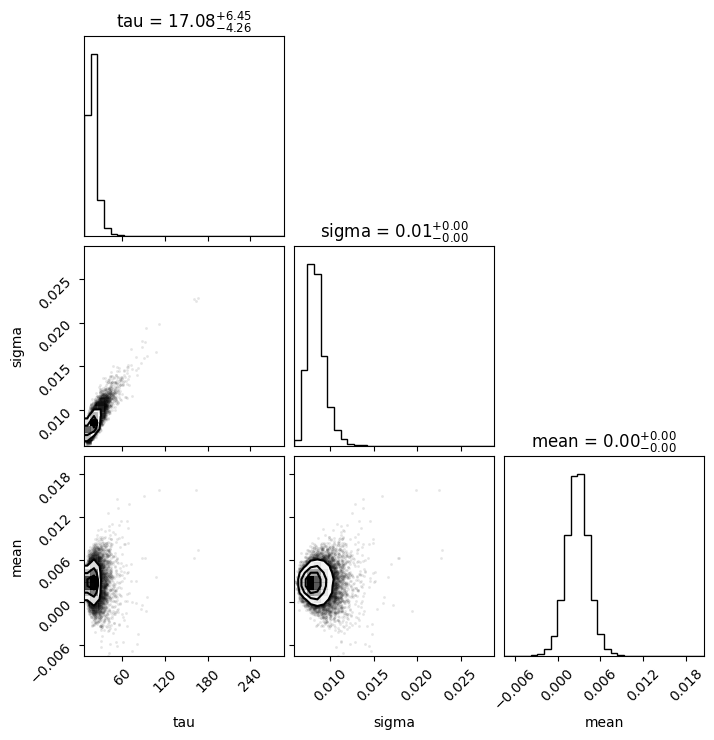

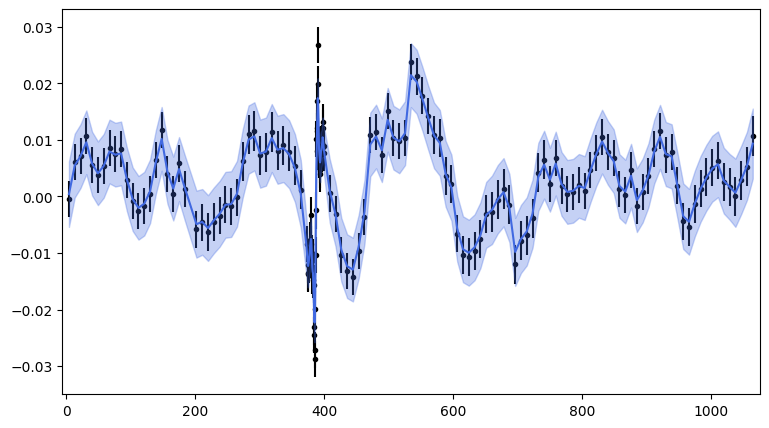

In [14]:
corner_plot(samples, list(priors.keys()), spikey_params)
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux_drw, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time, samples=samples)

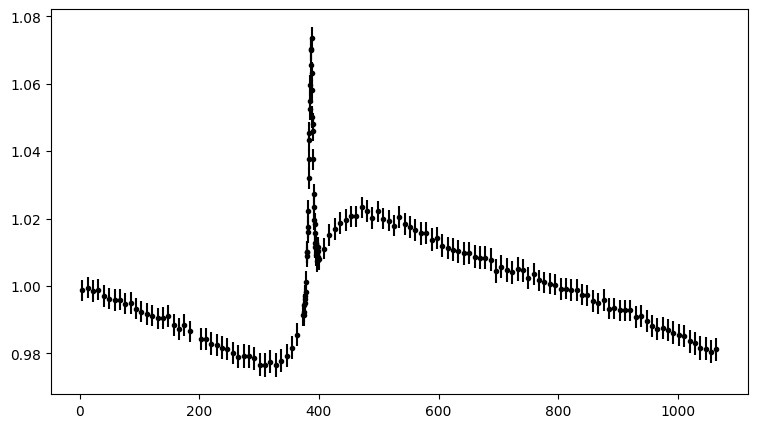

In [15]:
# Subtract DRW model and fit SMBHB model only
flux_smbhb = flux - samples['pred_gp_mean'].mean(axis=0)
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux_smbhb, flux_err, c='k', fmt='.');

In [16]:
%%time

priors = {
    'logM1': dist.Uniform(6, 11),
    'logM2': dist.Uniform(6, 11),
    'L': dist.Uniform(0, 1),
    'e': dist.Uniform(0, 1),
    'w': dist.Uniform(0, 360),
    'i': dist.Uniform(0, 90),
    'alpha': dist.Uniform(-4, 4),
    't0': dist.Uniform(0, 5),
    'P': dist.Uniform(0, 5),
    'z': spikey_params['z'],
    'vz': spikey_params['vz'],
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=None, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=4000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux_smbhb, yerr=flux_err, x_interp=time)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         L      0.21      0.20      0.10      0.02      0.52      2.03     10.93
         P      1.64      0.97      1.13      1.04      3.50      2.08      8.99
     alpha     -0.87      1.78     -0.47     -3.73      1.22      2.03     10.61
         e      0.50      0.36      0.29      0.10      0.97      2.05      8.26
         i     37.45      7.75     38.40     25.39     47.89      2.05      7.77
     logM1     10.19      0.61     10.29      9.30     10.99      2.04      8.64
     logM2      9.32      0.74      8.98      8.67     10.62      2.06      7.11
        t0      1.69      0.78      1.31      1.06      3.02      2.00     59.75
         w    112.89    118.87     85.57      0.04    278.92      2.00     92.00

Number of divergences: 6095
CPU times: user 2min 56s, sys: 121 ms, total: 2min 56s
Wall time: 1min 11s


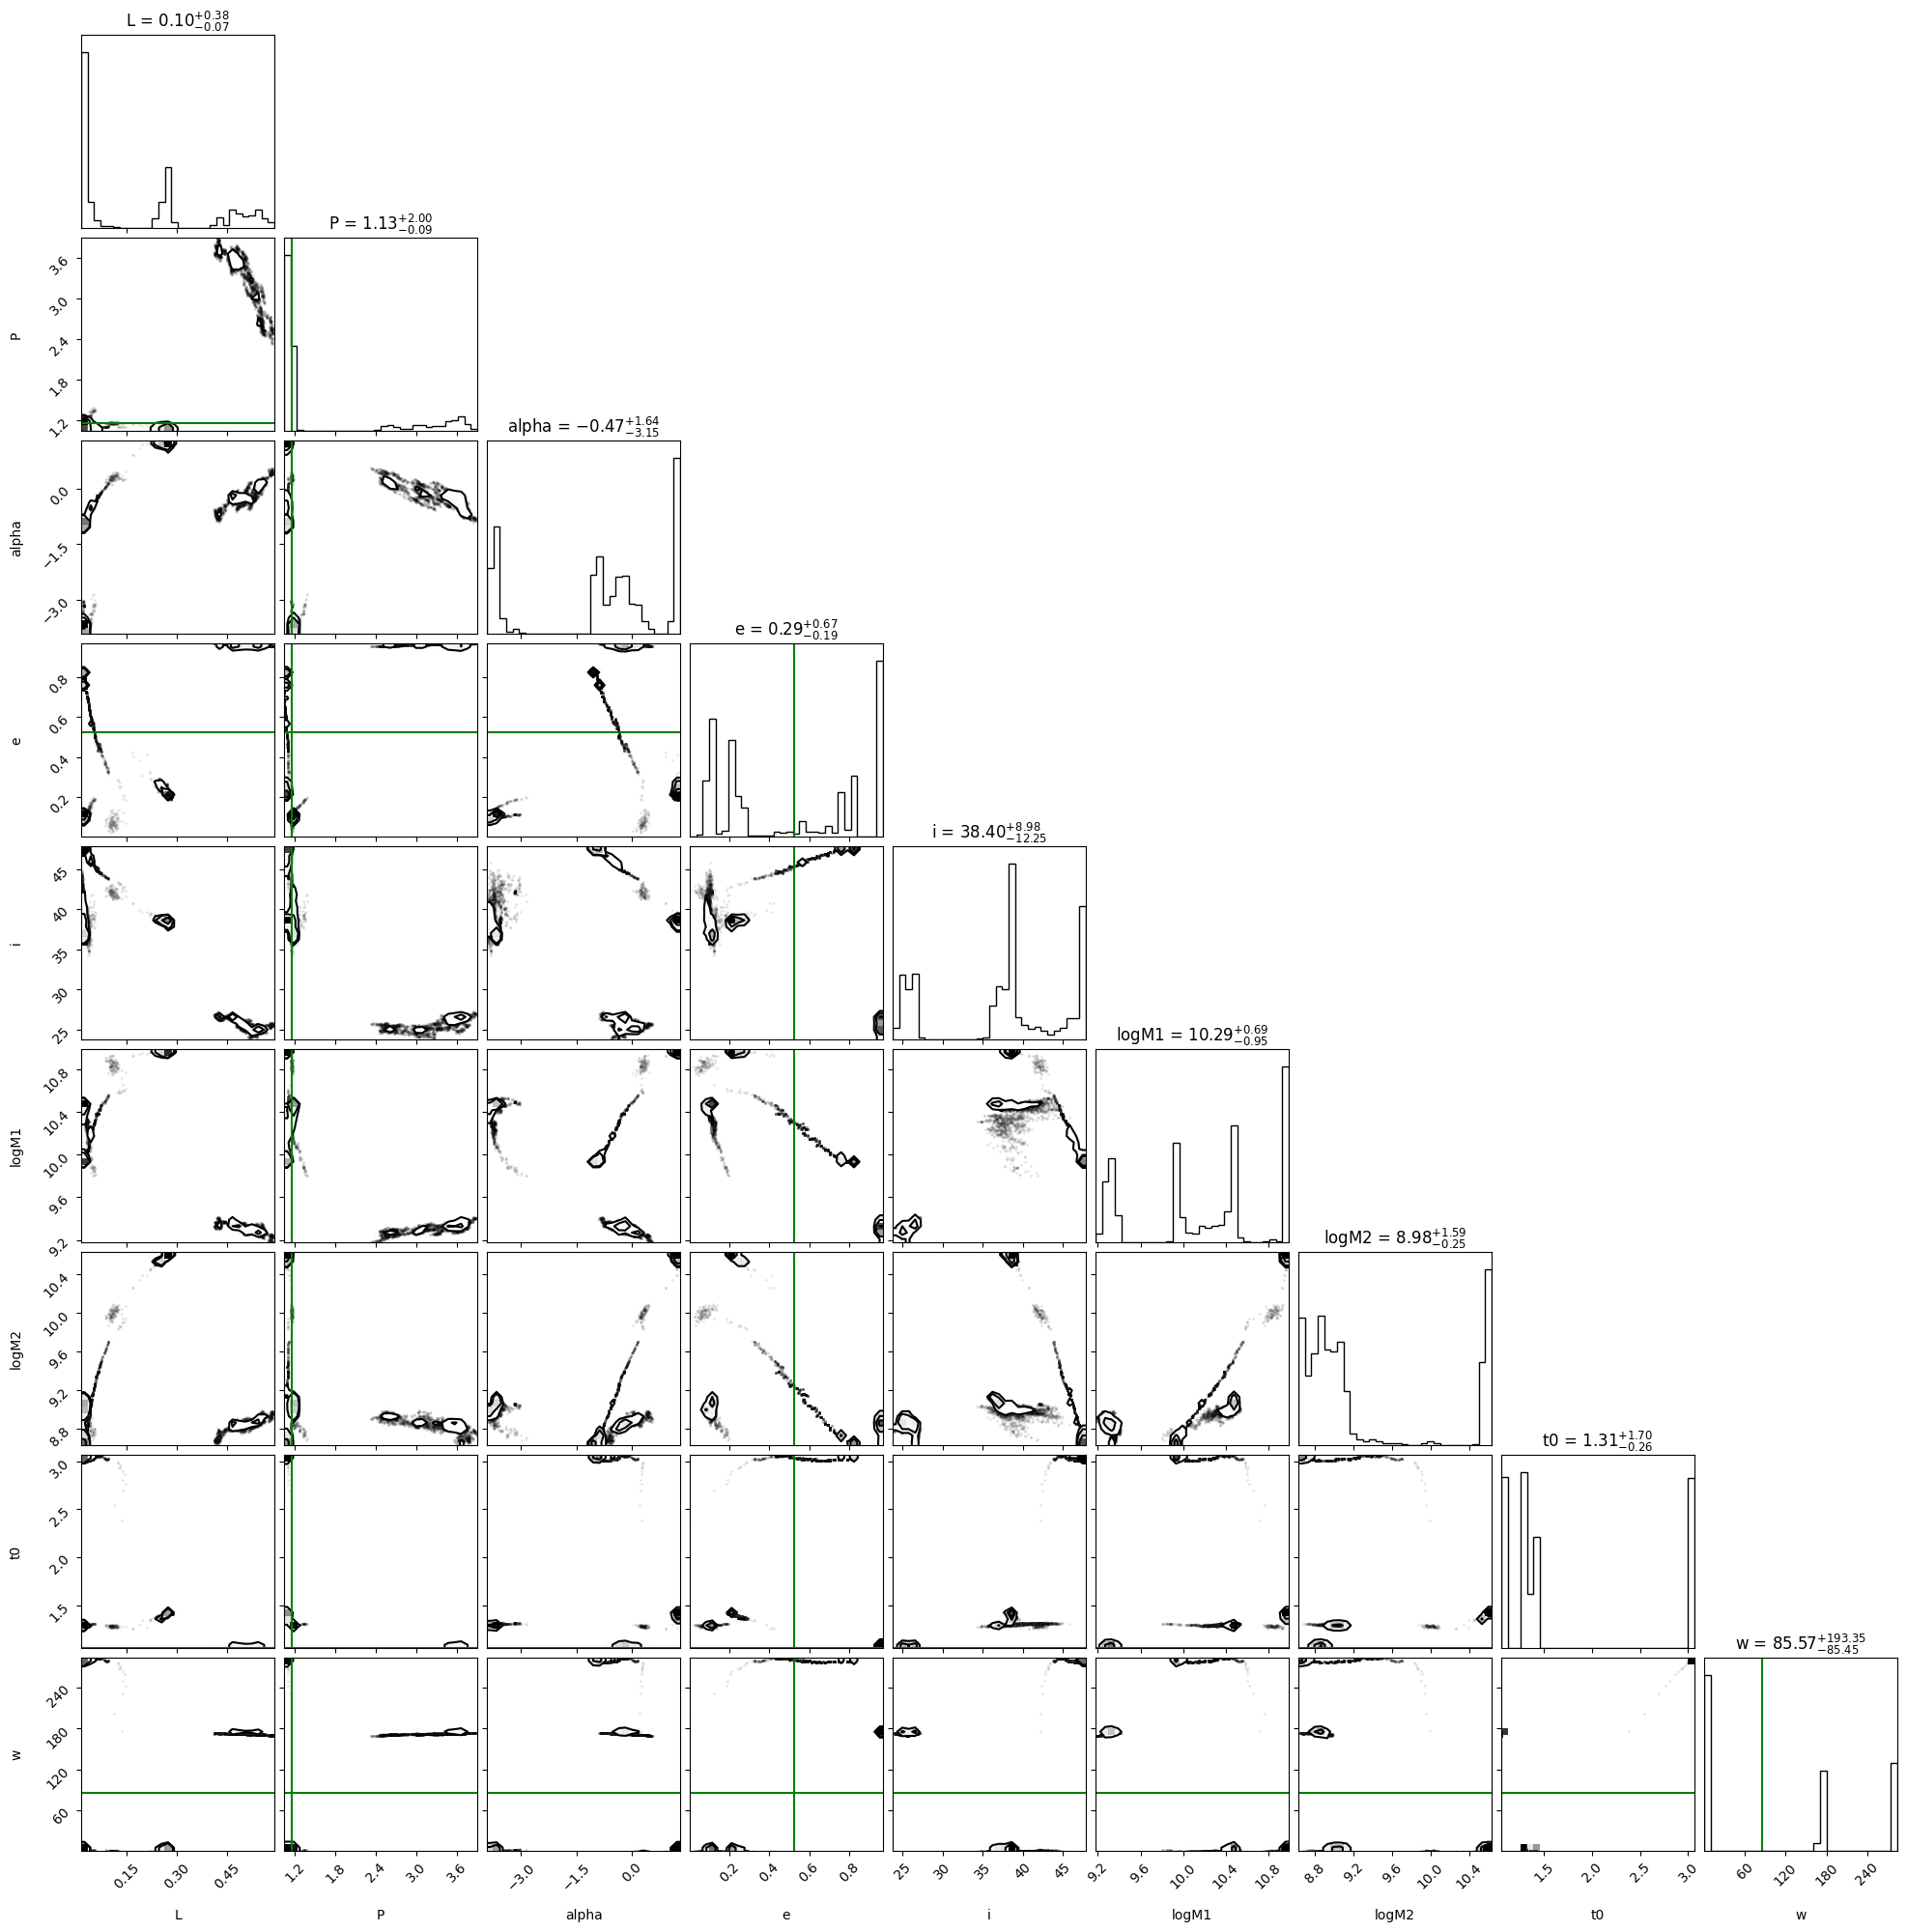

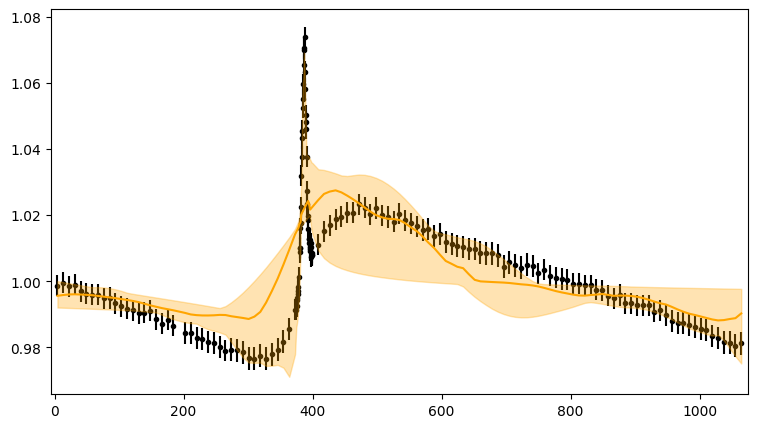

In [17]:
corner_plot(samples, true_params=spikey_params)
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux_smbhb, flux_err, fmt='.', c='k', zorder=-1)
predictive_posterior(ax, x=time, samples=samples)

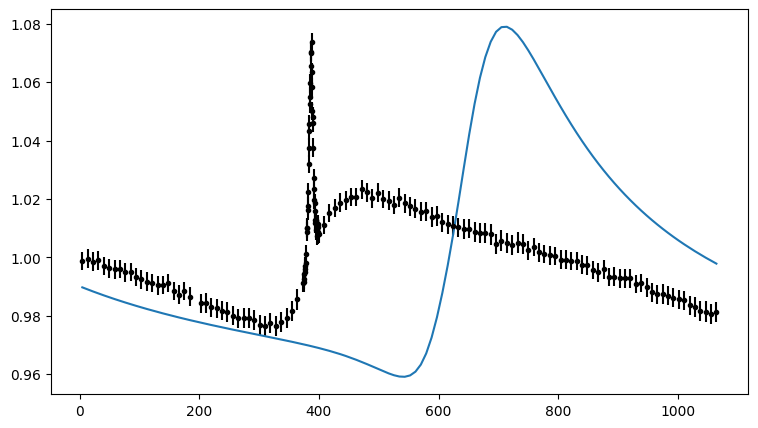

In [18]:
model_params = {
    'z': 0.918, 
    't0': samples['t0'].mean(), 
    'P': samples['P'].mean(), 
    'i': samples['i'].mean(), 
    'e': samples['e'].mean(), 
    'w': samples['w'].mean(),
    'L': samples['L'].mean(), 
    'alpha': samples['alpha'].mean(), 
    'vz': 0, 
    'logM1': samples['logM1'].mean(), 
    'logM2': samples['logM2'].mean(),
}
smbhb_partial = partial(smbhb_two_masses, **model_params)
sim_flux = jax.vmap(smbhb_partial)(time)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux_smbhb, flux_err, c='k', fmt='.')
ax.plot(time, sim_flux);

---
## 1. Modelling DRW
---

## Fitting only DRW

In [19]:
%%time

priors = {
    'tau': dist.LogNormal(jnp.log(200.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
    'mean': dist.Normal(jnp.mean(flux), 0.5),
}
time_interp = jnp.linspace(jnp.amin(time), jnp.amax(time), 500)

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=drw_kernel), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
print(mcmc.print_summary())

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      mean      1.00      0.01      1.00      0.99      1.01   5548.75      1.00
     sigma      0.02      0.01      0.02      0.01      0.03   4697.29      1.00
       tau     64.67     44.23     52.94     23.01    106.58   4350.41      1.00

Number of divergences: 0
None
CPU times: user 1min 30s, sys: 8.3 s, total: 1min 38s
Wall time: 50.3 s


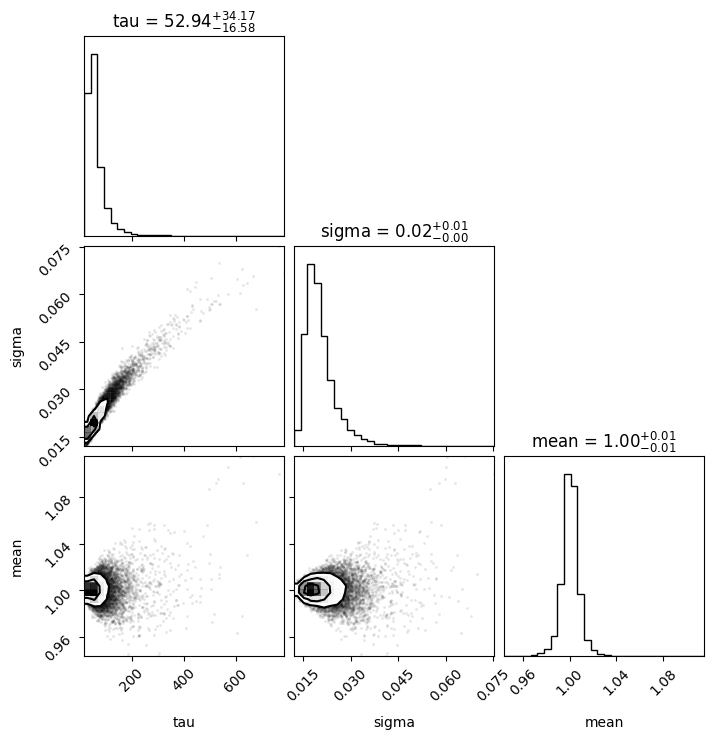

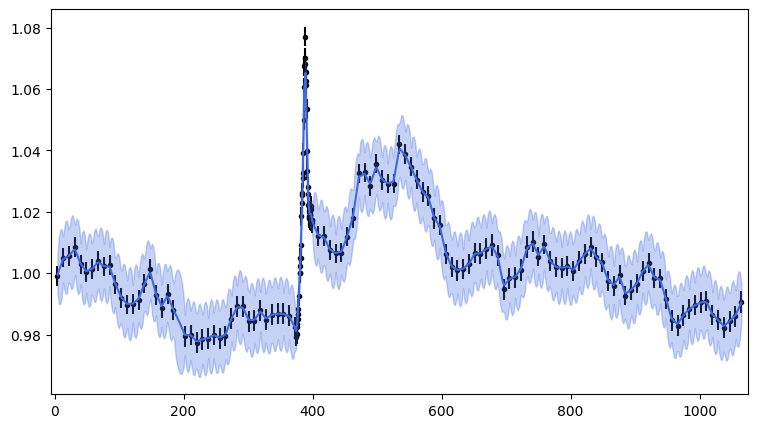

In [20]:
corner_plot(samples, list(priors.keys()), spikey_params)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time_interp, samples=samples)

DRW is perfectly capable of fitting the full time series

## Fitting DRW + fixed SMBHB model (Spikey parameters)

In [22]:
%%time

priors = {
    'tau': dist.LogNormal(jnp.log(200.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors | spikey_params, build_kernel=drw_kernel, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     sigma      0.01      0.00      0.01      0.01      0.01   6673.95      1.00
       tau     23.77     11.60     21.13     10.96     36.26   5466.56      1.00

Number of divergences: 0
CPU times: user 1min 13s, sys: 6.18 s, total: 1min 19s
Wall time: 38 s


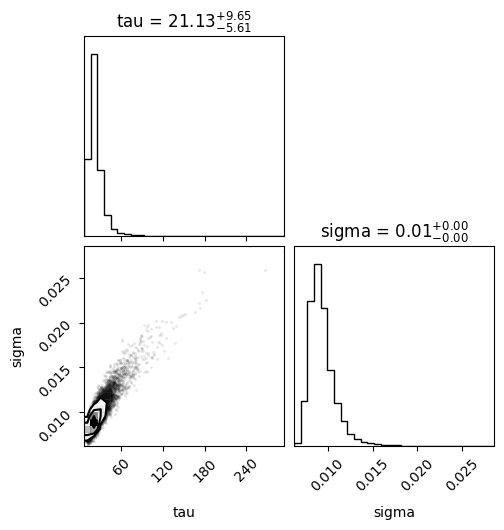

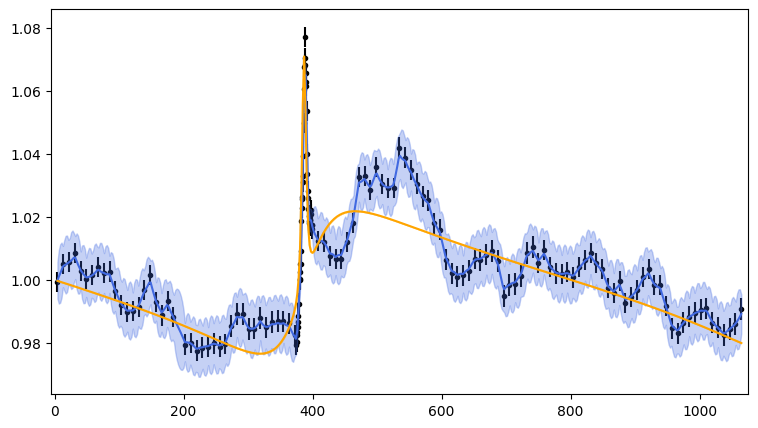

In [23]:
corner_plot(samples, list(priors.keys()), spikey_params)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time_interp, samples=samples)

With the SMBHB model as mean, DRW variance and time scale are smaller than in the previous case.

## Fitting DRW + fixed SMBHB model (wrong parameters)

In [24]:
spikey_params_wrong = spikey_params.copy()
spikey_params_wrong['e'] = 0.0

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors | spikey_params_wrong, build_kernel=drw_kernel, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     sigma      0.01      0.00      0.01      0.01      0.02   7274.41      1.00
       tau     22.84      8.64     21.01     11.91     33.20   6583.97      1.00

Number of divergences: 0


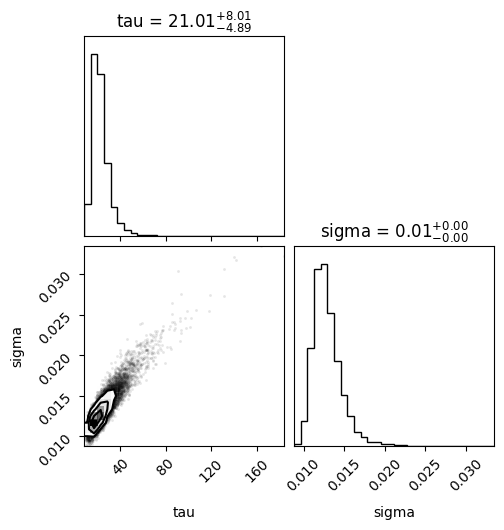

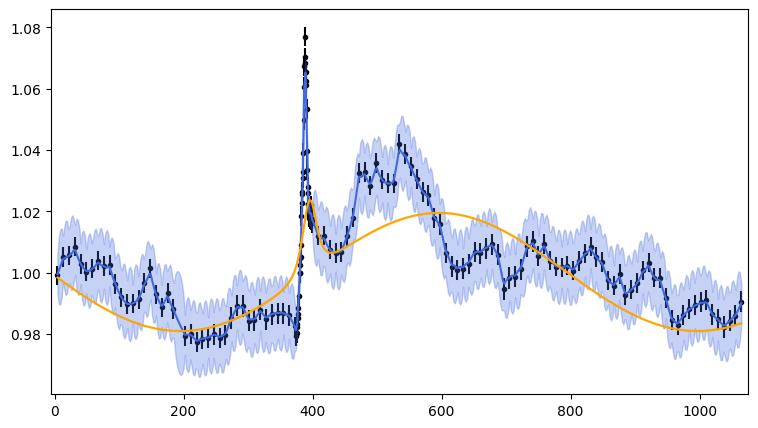

In [25]:
corner_plot(samples, list(priors.keys()), spikey_params)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time_interp, samples=samples)

As shown before, it does not really matter if the SMBHB model is "wrong", the DRW can compensate.

---
## 2. Modelling SMBHB model
---

### Fitting SMBHB model (uniform priors) without DRW

In [27]:
%%time

priors = {
    'logM1': dist.Uniform(6., 11.),
    'logM2': dist.Uniform(6., 11.),
    'L': dist.Uniform(0., 1.),
    'e': dist.Uniform(0.01, 0.99),
    'w': dist.Uniform(0, 360),
    'i': dist.Uniform(0, 90),
    'alpha': dist.Uniform(-4, 4),
    't0': dist.Uniform(0, 5),
    'P': dist.Uniform(0, 5),
    'z': spikey_params['z'],
    'vz': spikey_params['vz'],
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=None, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         L      0.24      0.18      0.19      0.02      0.46      2.09      5.16
         P      1.26      0.14      1.16      1.11      1.46      2.14      4.43
     alpha     -1.92      1.43     -1.96     -3.99      0.15      2.05      7.12
         e      0.32      0.18      0.37      0.01      0.52      2.01     12.32
         i     75.54     18.67     85.89     43.35     88.39      2.00     54.05
     logM1      7.83      1.87      7.13      6.00     10.88      2.00     42.19
     logM2      7.43      1.60      6.75      6.04     10.02      2.00     26.35
        t0      1.32      0.16      1.39      1.04      1.47      2.03      8.69
         w     21.81     33.50      1.65      0.06     79.79      2.02     11.00

Number of divergences: 6
CPU times: user 6min 1s, sys: 196 ms, total: 6min 1s
Wall time: 1min 37s


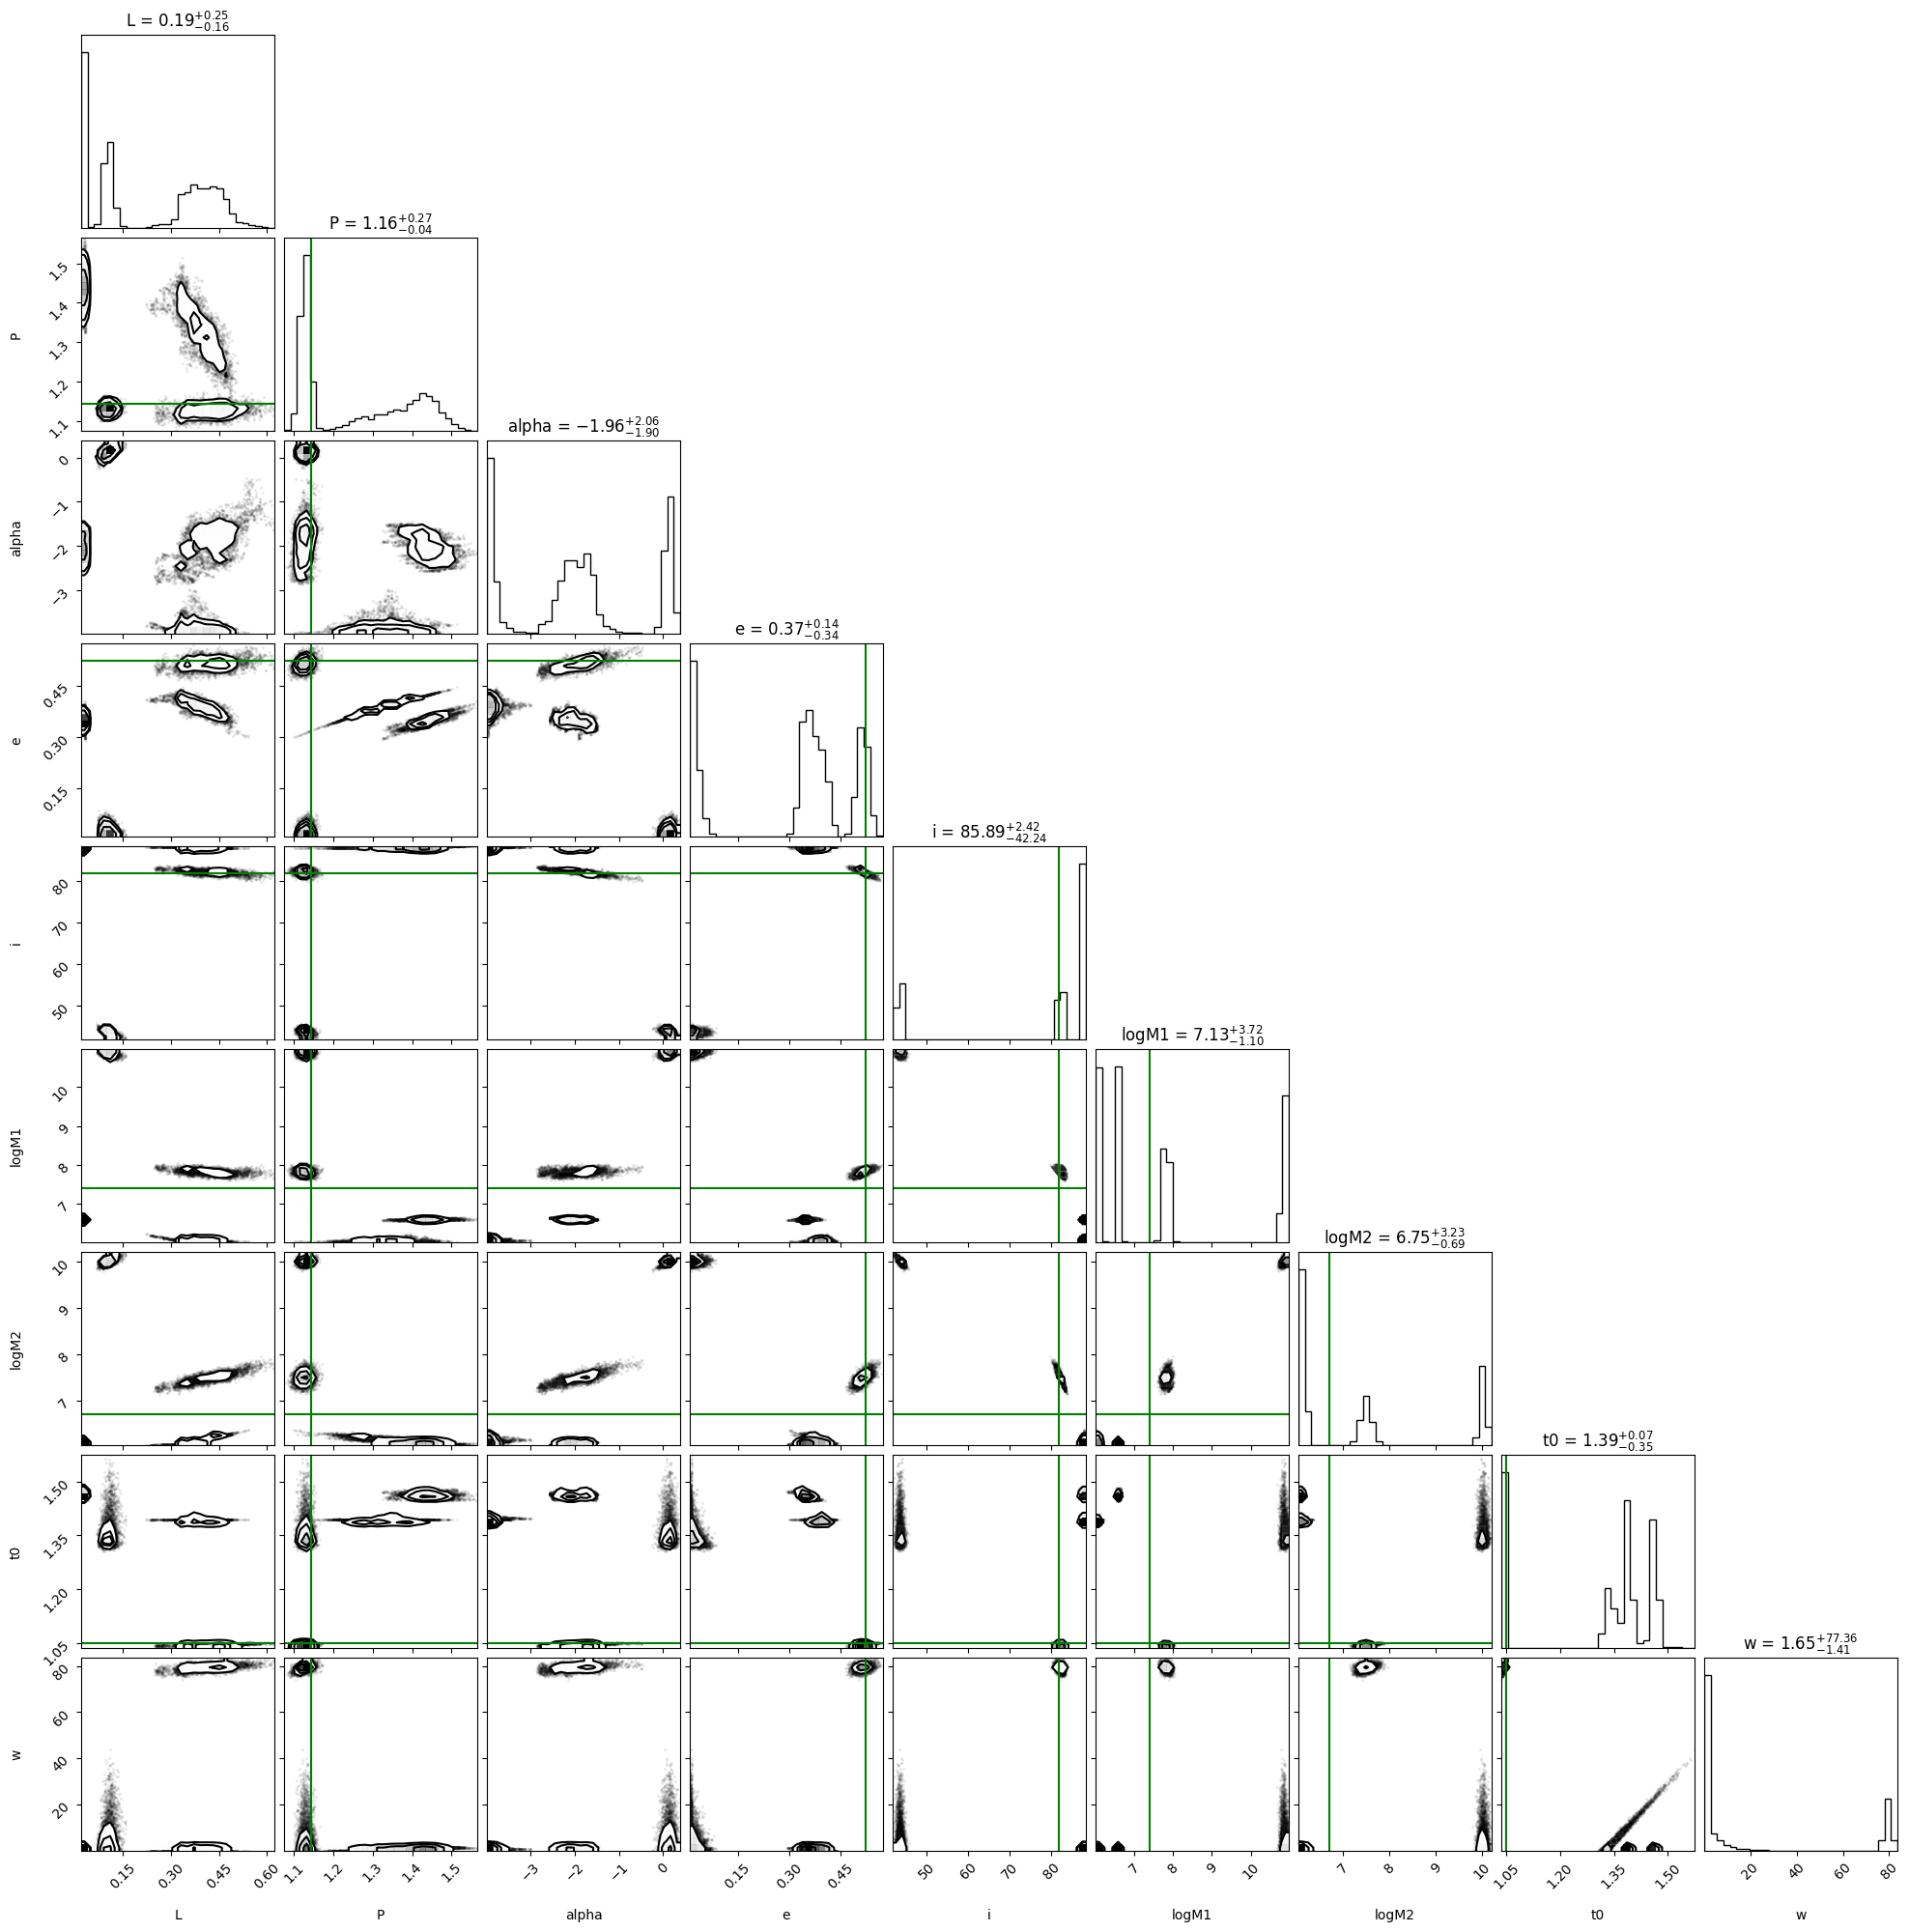

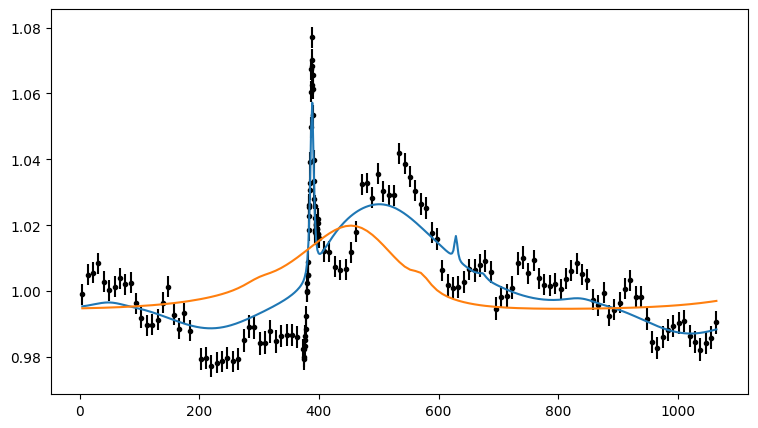

In [28]:
corner_plot(samples, true_params=spikey_params)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-1)
# predictive_posterior(ax, x=time, samples=samples)
ax.plot(time_interp, samples['pred_smbhb'].mean(axis=0))

# Let's also plot the mean value
spikey_params = {
    'z': 0.918, 
    't0': samples['t0'].mean(), 
    'P': samples['P'].mean(), 
    'i': samples['i'].mean(), 
    'e': samples['e'].mean(), 
    'w': samples['w'].mean(),
    'L': samples['L'].mean(), 
    'alpha': samples['alpha'].mean(), 
    'vz': 0, 
    'logM1': samples['logM1'].mean(), 
    'logM2': samples['logM2'].mean(),
}

smbhb_partial = partial(smbhb_two_masses, **spikey_params)
sim_flux = jax.vmap(smbhb_partial)(time)
ax.plot(time, sim_flux);

### Fitting SMBHB model (uniform priors) with DRW

In [29]:
%%time

priors = {
    'logM1': dist.Uniform(6., 11.),
    'logM2': dist.Uniform(6., 11.),
    'L': dist.Uniform(0., 1.),
    'e': dist.Uniform(0.01, 0.99),
    'w': dist.Uniform(0, 360),
    'i': dist.Uniform(0, 90),
    'alpha': dist.Uniform(-4, 4),
    't0': dist.Uniform(0, 5),
    'P': dist.Uniform(0, 5),
    'z': spikey_params['z'],
    'vz': spikey_params['vz'],
    'tau': dist.LogNormal(jnp.log(200.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=drw_kernel, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         L      0.47      0.19      0.42      0.24      0.81      5.97      1.29
         P      2.01      0.77      1.81      0.98      3.00     11.90      1.23
     alpha      2.22      1.24      2.50      0.48      3.83      2.18      3.77
         e      0.80      0.16      0.82      0.54      0.96      2.06      6.49
         i     55.21     29.26     72.19     14.80     86.35      2.07      5.28
     logM1      7.89      0.89      7.83      6.86      9.58      4.67      1.61
     logM2      8.04      1.36      8.10      6.34      9.55      2.10      5.06
     sigma      0.02      0.01      0.01      0.01      0.02      3.70      1.55
        t0      3.61      1.47      4.40      1.07      4.58      2.01     19.61
       tau    239.20    164.10    204.94     67.90    430.27     12.66      1.19
         w    163.40     98.82    143.38     51.90    328.73      2.03      7.85

Number of divergences: 113

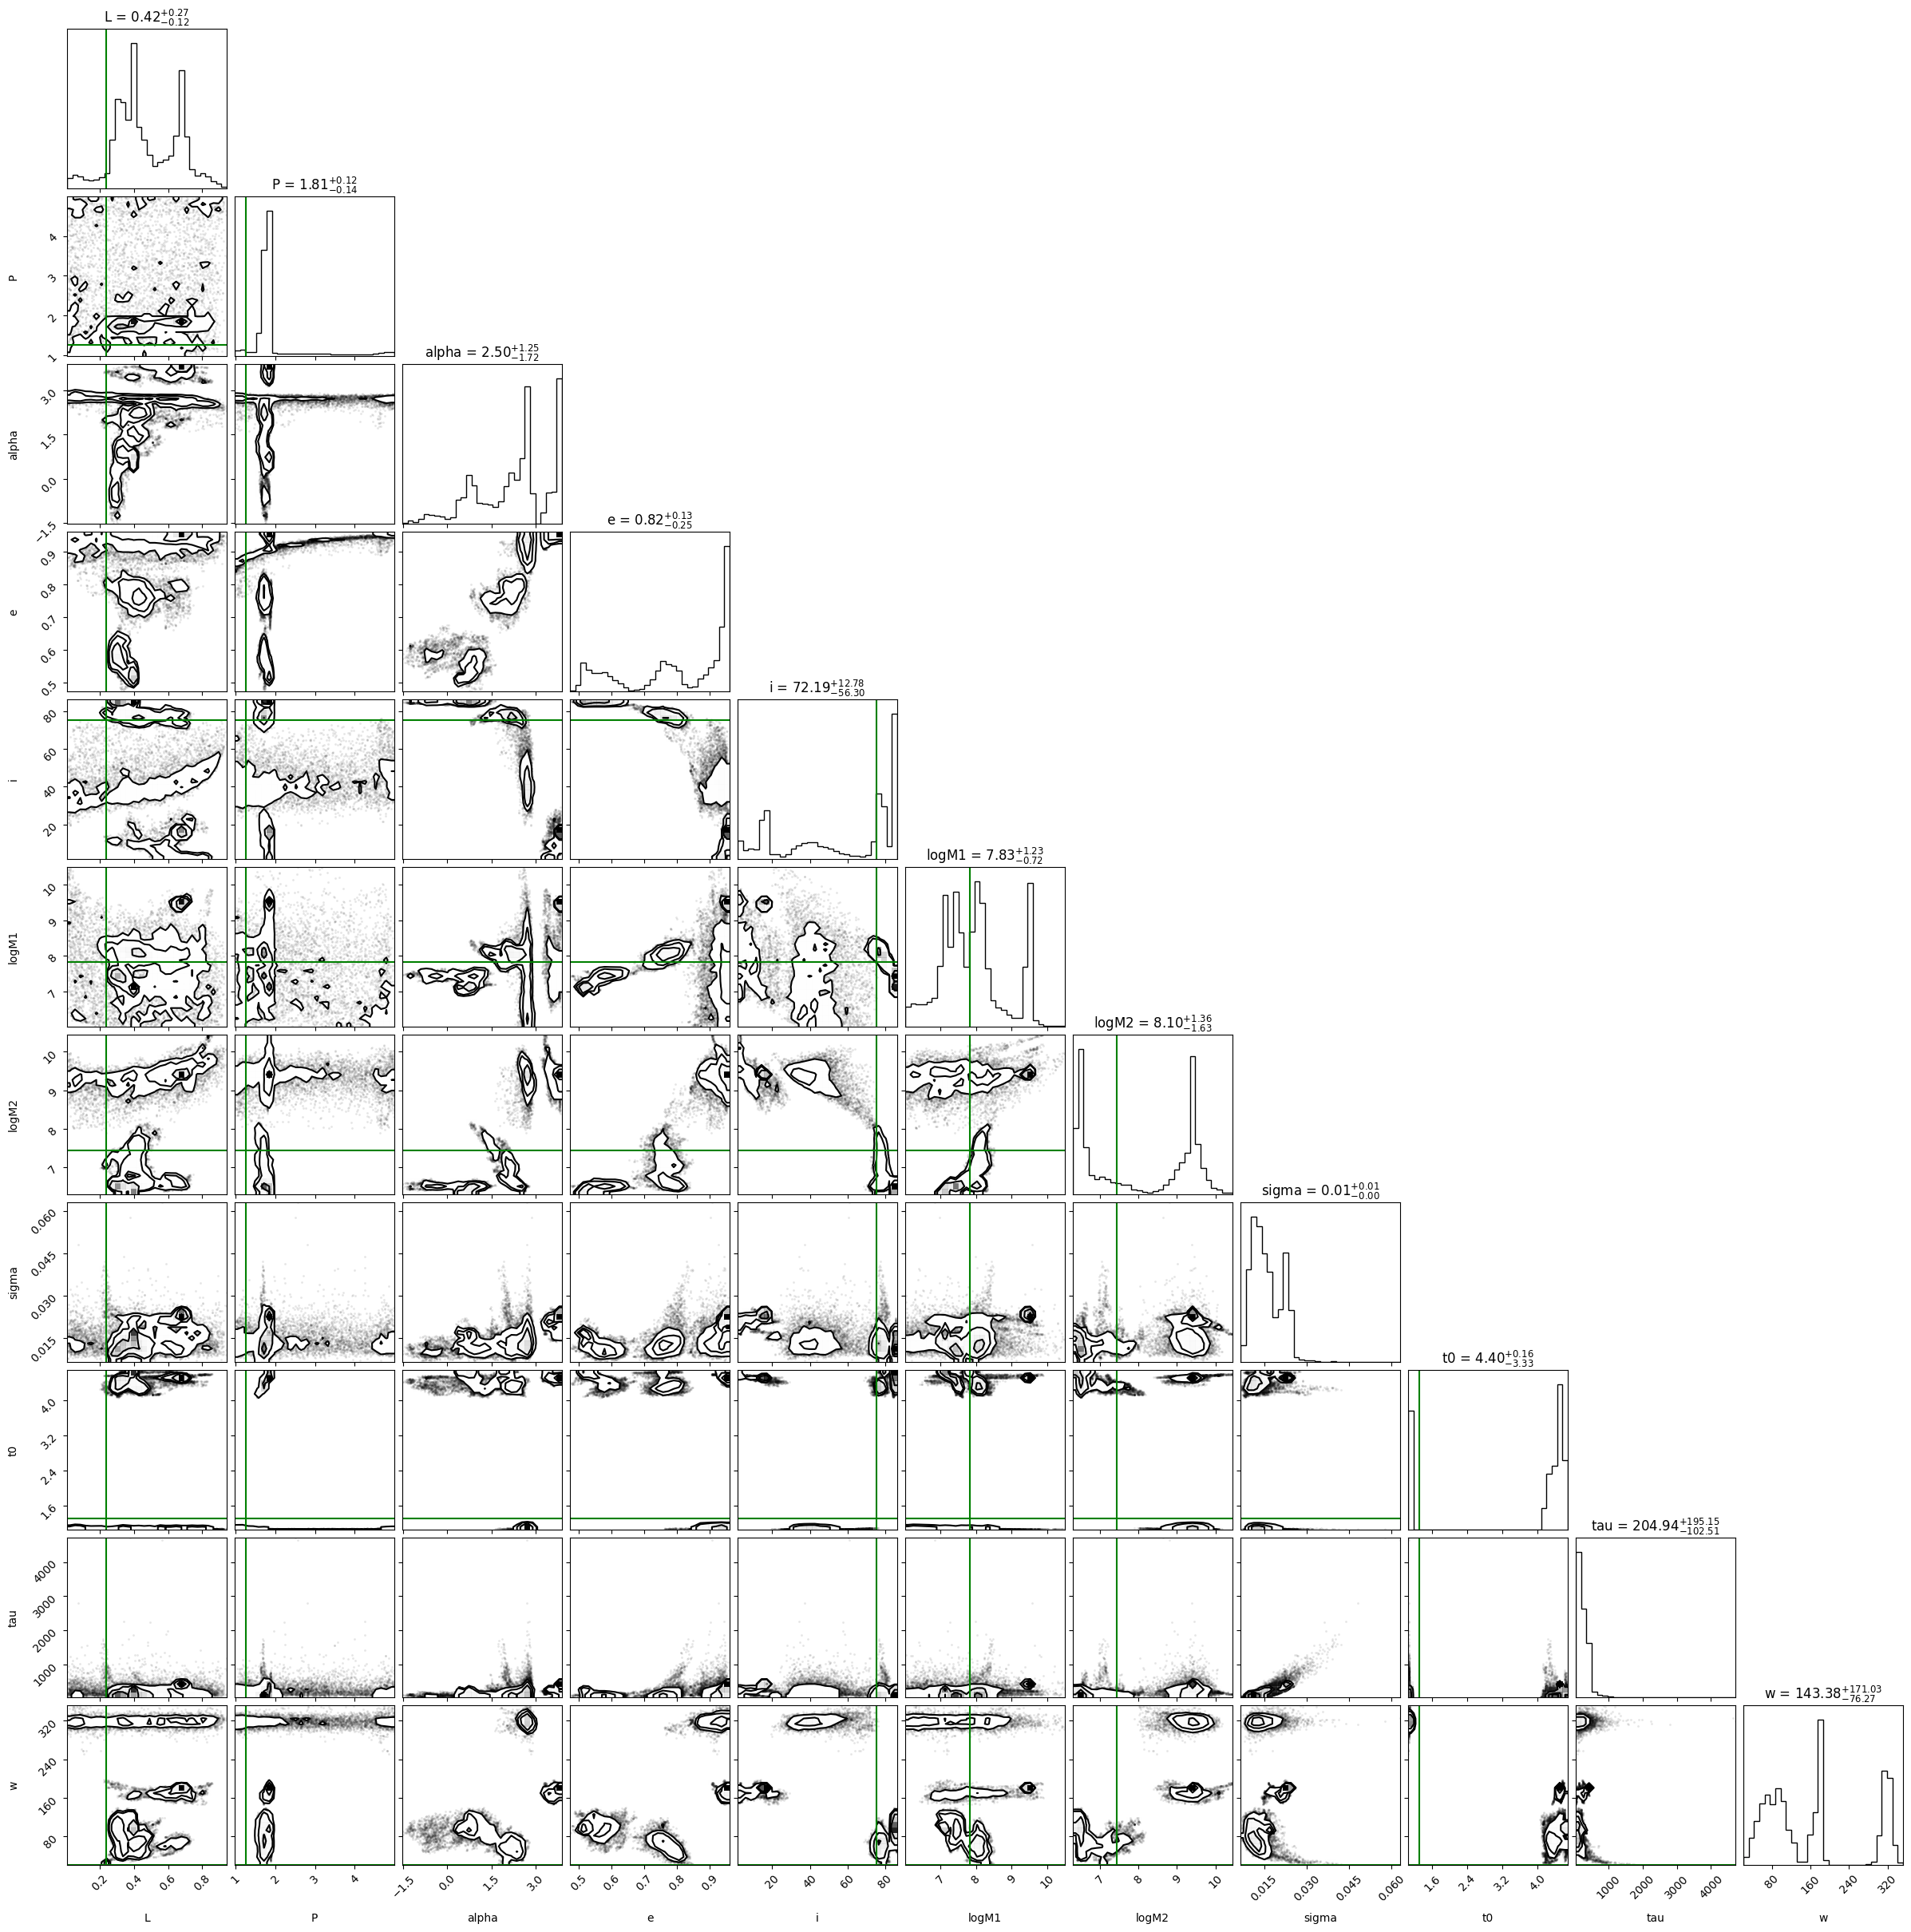

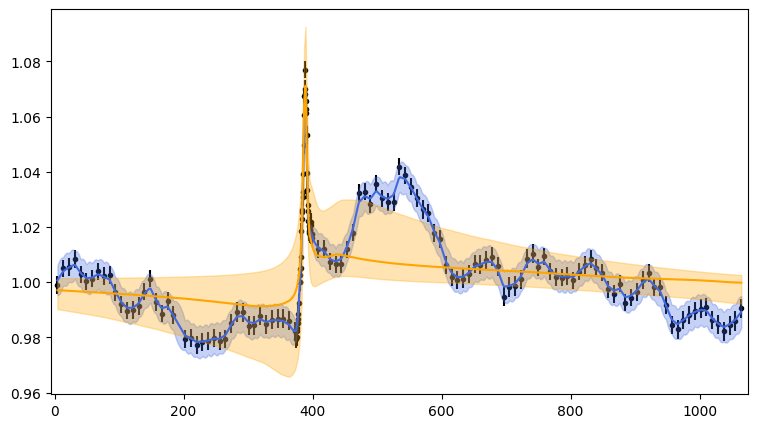

In [30]:
corner_plot(samples, true_params=spikey_params)
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-10)
predictive_posterior(ax, x=time_interp, samples=samples)

### Fitting SMBHB model (uniform priors) with DRW (constrained DRW)

In [31]:
%%time

priors = {
    'logM1': dist.Uniform(6, 11),
    'logM2': dist.Uniform(6, 11),
    'L': dist.Uniform(0, 1),
    'e': dist.Uniform(0, 1),
    'w': dist.Uniform(0, 360),
    'i': dist.Uniform(0, 90),
    'alpha': dist.Uniform(-4, 4),
    't0': dist.Uniform(0, 5),
    'P': dist.Uniform(0, 5),
    'z': spikey_params['z'],
    'vz': spikey_params['vz'],
    'tau': 21,
    'sigma': 0.01,
}

nuts_kernel = NUTS(
    make_tinygp_model(priors=priors, build_kernel=drw_kernel, build_mean=smbhb_mean_builder), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time_interp)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         L      0.46      0.28      0.41      0.02      0.89      8.59      1.20
         P      1.60      0.86      1.25      0.97      2.94      3.09      1.67
     alpha     -0.19      1.85      0.21     -3.16      2.62     10.43      1.16
         e      0.65      0.20      0.60      0.43      0.97      2.40      2.47
         i     70.33     22.45     81.88     26.81     87.32      2.32      2.64
     logM1      7.59      0.65      7.50      6.56      8.63     30.30      1.10
     logM2      7.06      0.70      7.00      6.00      7.98      6.06      1.24
        t0      1.62      0.99      1.06      0.98      3.40      2.02      9.57
         w    148.86     75.24    134.56     67.25    273.67      2.04      6.95

Number of divergences: 901
CPU times: user 10min 21s, sys: 21.3 s, total: 10min 42s
Wall time: 3min 46s


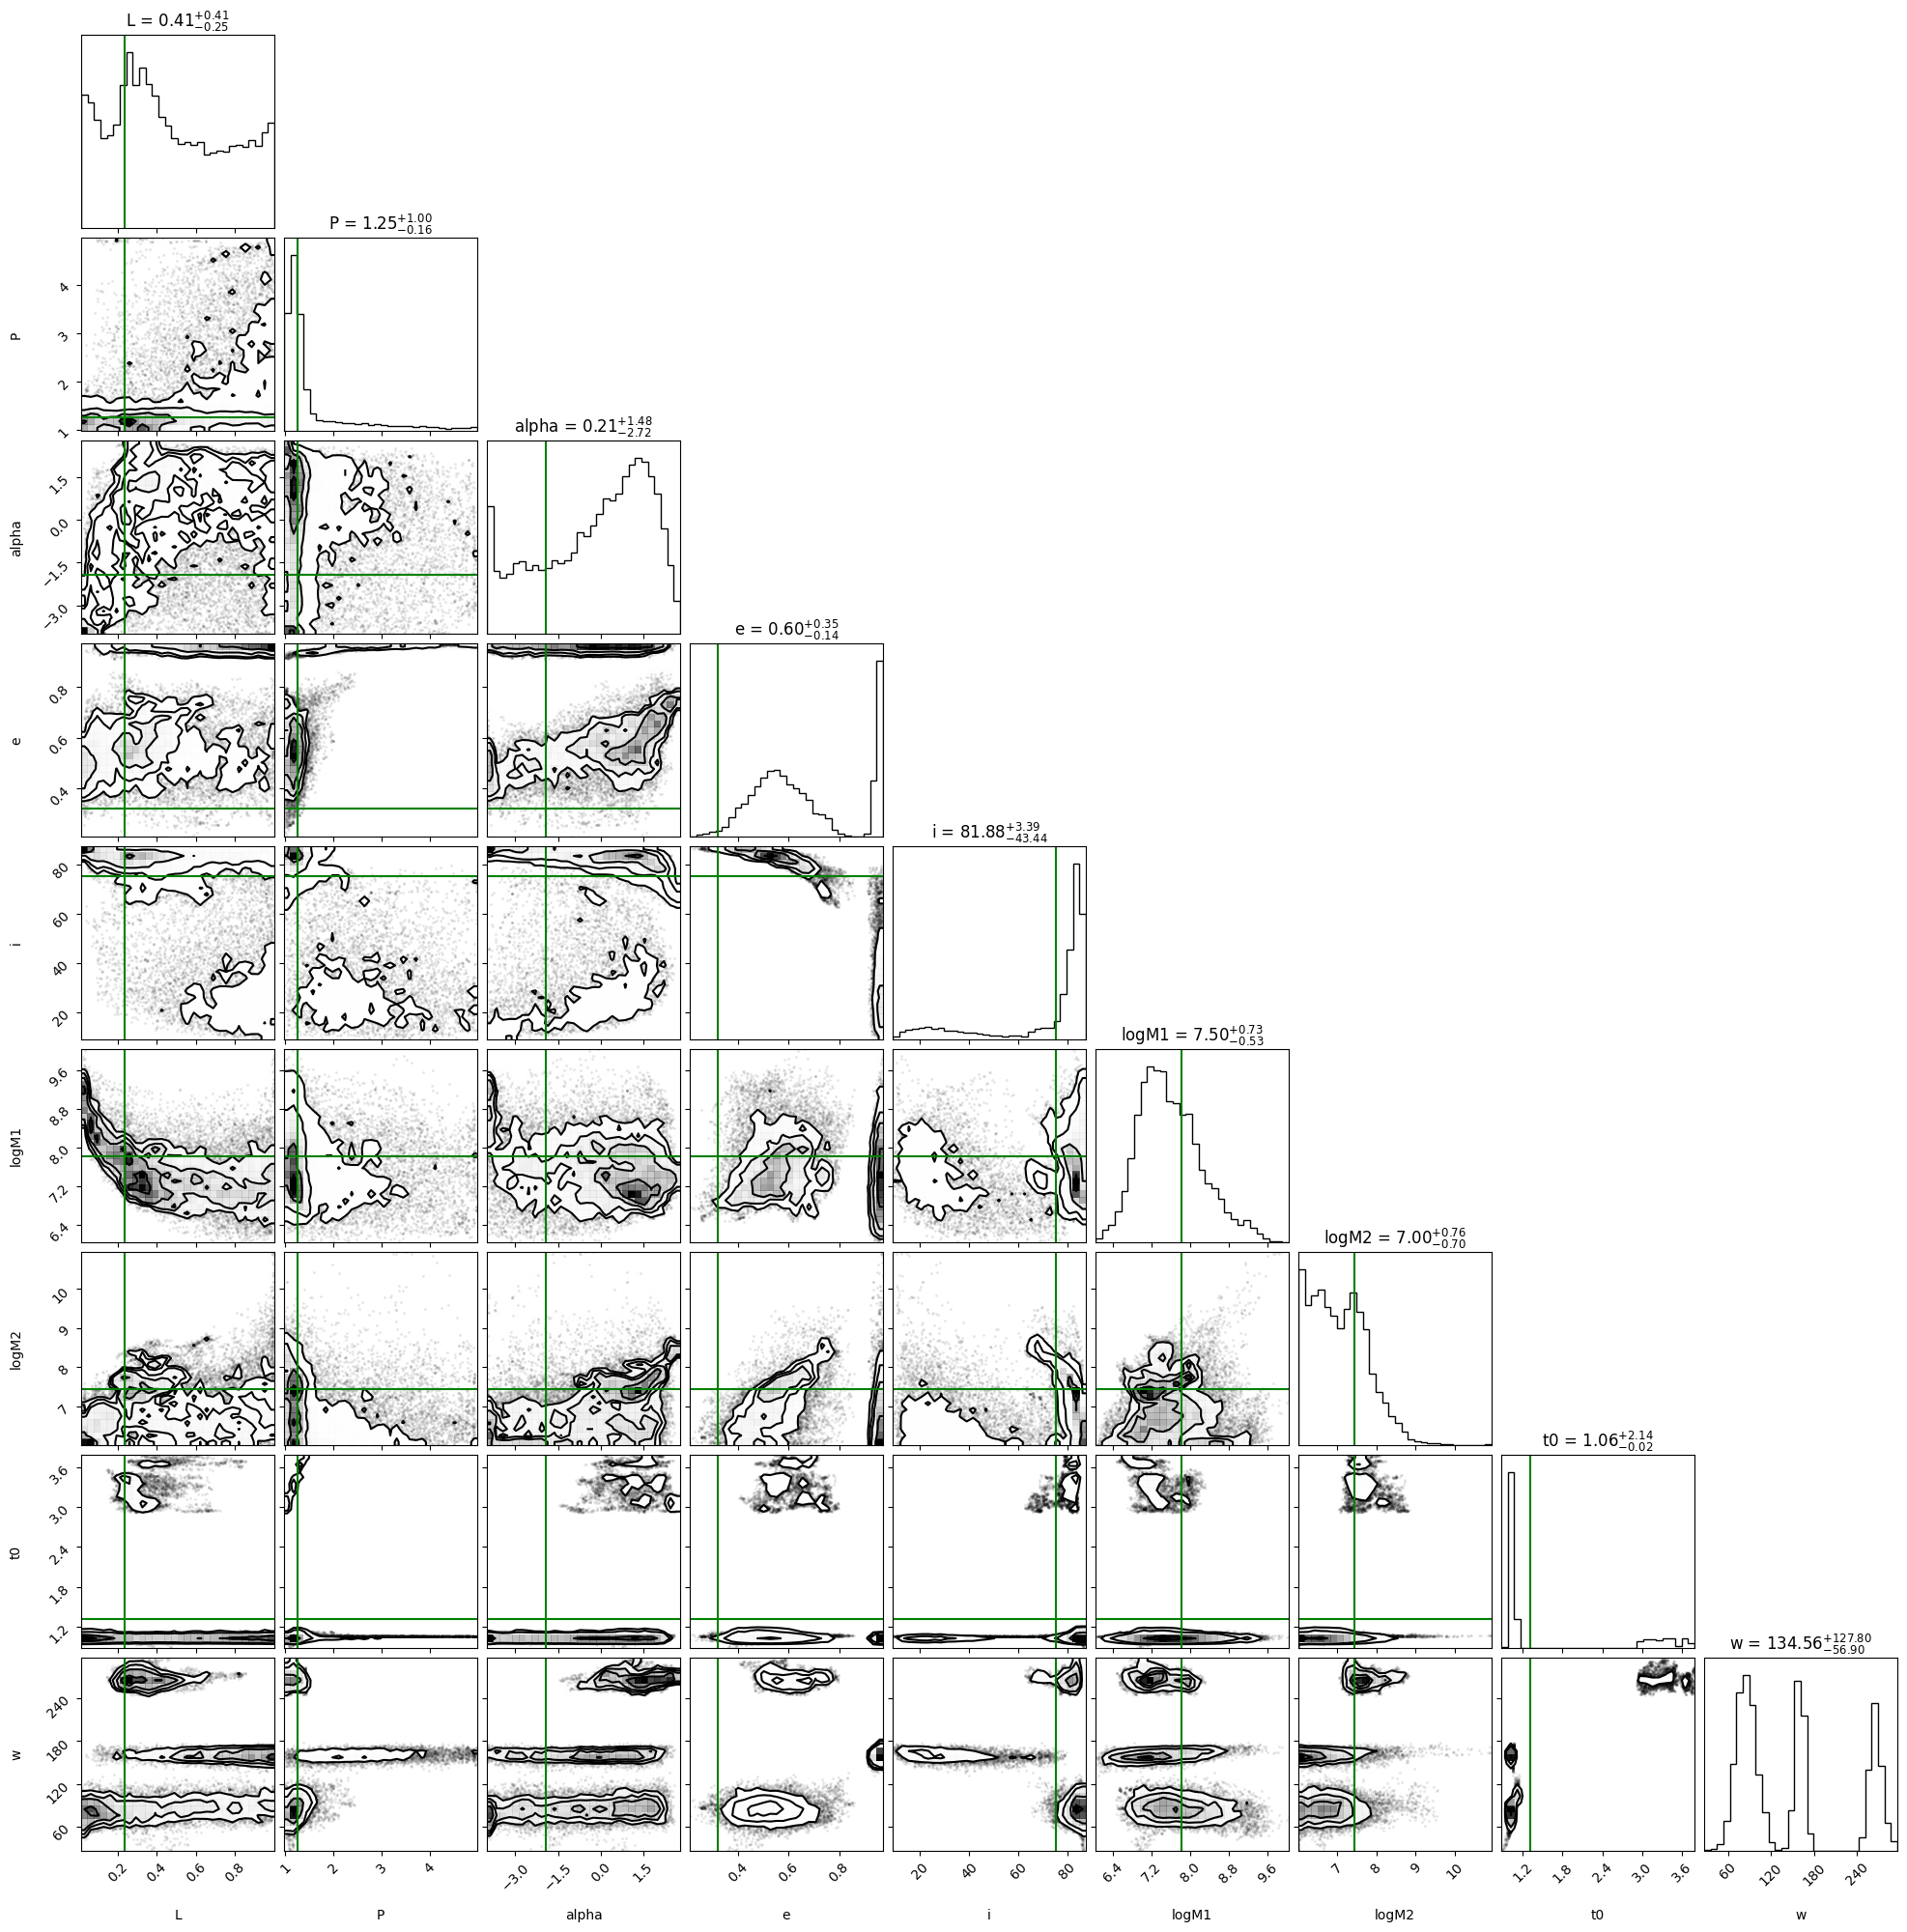

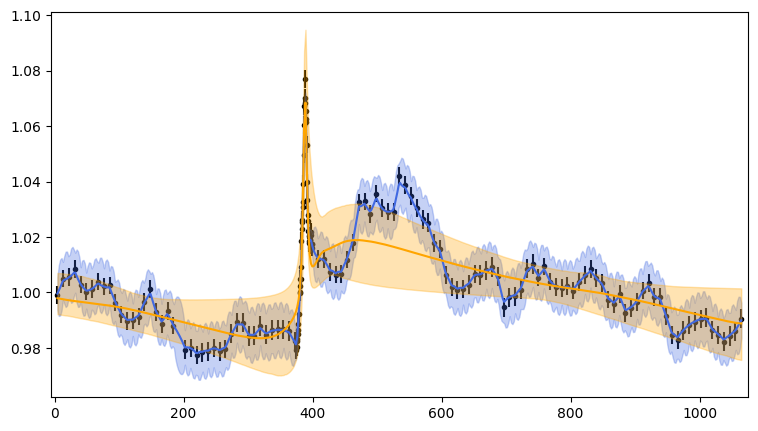

In [32]:
corner_plot(samples, true_params=spikey_params)
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(time, flux, flux_err, fmt='.', c='k', zorder=-1)
predictive_posterior(ax, x=time_interp, samples=samples)